# 02 — Face preprocessing and embedding pipeline

**Goal:** check whether a fixed pretrained face model can turn LFW images into usable embeddings.

This stage uses the first 10 genuine and first 10 impostor pairs from the development-training file. These 20 pairs are a deterministic debugging subset, not a performance benchmark.

Run after Commit 3 passes. Use the project Python 3.13 environment defined in requirements.txt and restart the Jupyter kernel after installing it. The first model load downloads recognition weights; it can take several minutes.


In [1]:
from pathlib import Path
import sys
import json

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src' / 'embedding_smoke_test.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Launch Jupyter from inside biometrics-project1.')
sys.path.insert(0, str(ROOT / 'src'))
from embedding_smoke_test import run_smoke_test
print('Project:', ROOT)
print('Python:', sys.executable)


Project: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification
Python: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification/.venv/bin/python


## 1. Run the pipeline
MTCNN detects candidate faces. We select the highest-confidence box containing the image center, with probability at least 0.90. LFW defines the target face at the image center. Missing, low-confidence, or noncentral detections are recorded as failures; no fallback image is silently substituted.

The selected box is cropped and resized to 160 × 160. This is bounding-box cropping, not a new landmark-based geometric alignment. LFW images are already the funneled version. RGB values are standardized once using `(pixel - 127.5) / 128.0`, then passed to the VGGFace2-pretrained InceptionResnetV1 in evaluation mode. No model training is performed.

Future quality degradations will be applied to these original-condition crops before standardization. Detection will not be rerun for each degraded version.


In [2]:
report = run_smoke_test(ROOT)
keys = ['status', 'unique_images', 'successful_images', 'failed_images',
        'scored_pairs', 'excluded_pairs', 'scored_same_pairs',
        'scored_different_pairs', 'repeat_max_abs_difference',
        'self_similarity', 'checks']
print(json.dumps({key: report[key] for key in keys}, indent=2))


Loading MTCNN and VGGFace2-pretrained FaceNet on CPU ...


1/33: ok


2/33: ok


3/33: ok


4/33: ok


...

31/33: ok


32/33: ok


33/33: ok


Saved results/metrics/embedding_smoke_test.json


{
  "status": "completed",
  "unique_images": 33,
  "successful_images": 33,
  "failed_images": 0,
  "scored_pairs": 20,
  "excluded_pairs": 0,
  "scored_same_pairs": 10,
  "scored_different_pairs": 10,
  "repeat_max_abs_difference": 0.0,
  "self_similarity": 1.0,
  "checks": {
    "finite_unit_512d_embeddings": true,
    "repeat_embedding_close": true,
    "self_similarity_near_one": true,
    "both_pair_classes_scored": true
  }
}


## 2. Inspect crop selection
Inspect the first six successful crops against their source images. Check that the selected face is the labeled central face and that the crop is usable. Numerical checks alone cannot establish correct crop selection. Review all failed image records separately below.


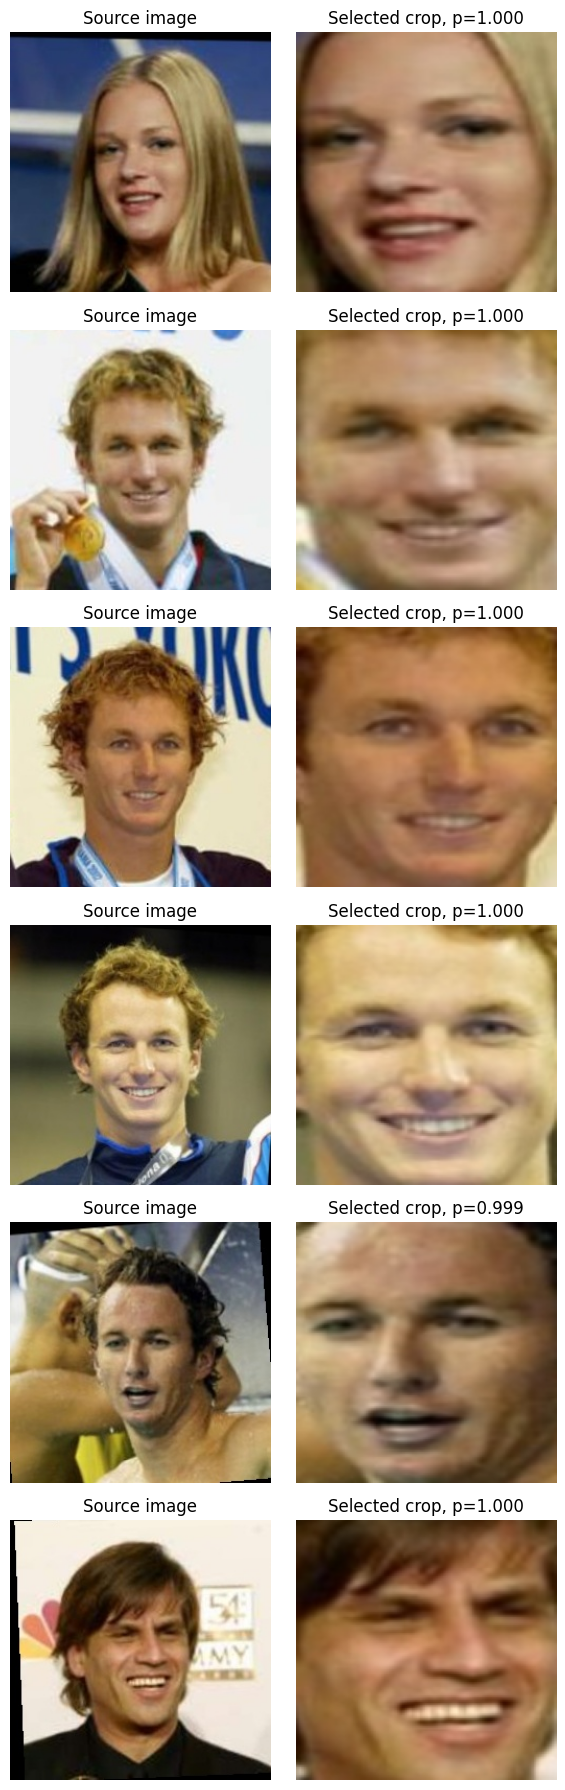

Failure records:
[]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

successful = [row for row in report['images'] if row['status'] == 'ok']
examples = successful[:6]
fig, axes = plt.subplots(len(examples), 2, figsize=(6, 3 * len(examples)), squeeze=False)
for index, row in enumerate(examples):
    with Image.open(ROOT / 'data/lfw_home/lfw_funneled' / row['path']) as image:
        axes[index, 0].imshow(image.convert('RGB'))
    crop = np.load(ROOT / row['crop_path'], allow_pickle=False)
    axes[index, 1].imshow(np.clip(crop.transpose(1, 2, 0), 0, 255).astype(np.uint8))
    axes[index, 0].set_title('Source image')
    axes[index, 1].set_title(f"Selected crop, p={row['probability']:.3f}")
    for ax in axes[index]:
        ax.axis('off')
fig.tight_layout()
plt.show()
failures = [row for row in report['images'] if row['status'] != 'ok']
print('Failure records:')
print(json.dumps(failures, indent=2))


## 3. Inspect sample similarities
Cosine similarity compares embeddings; higher values indicate more similar representations. It is not a calibrated match probability. Ground-truth labels below come from LFW, not from a decision rule.

We intentionally do not select a threshold or calculate accuracy on this debugging subset. Any class separation or overlap is an observation about these examples only. Pairs with preprocessing failures remain in the CSV with no score and an explicit status.


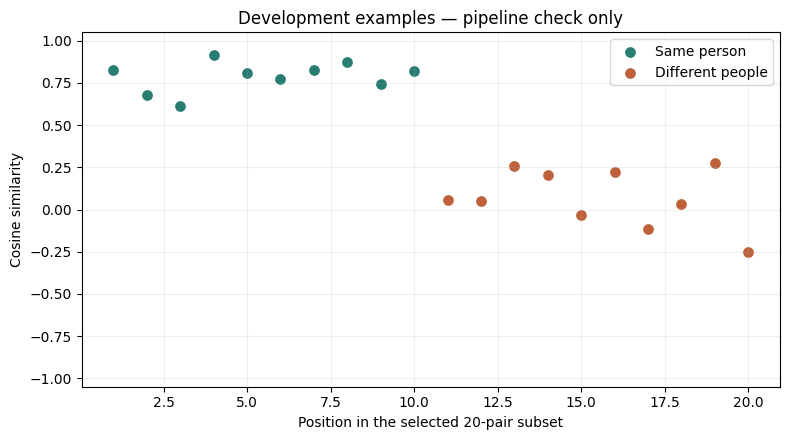

pair    0 | label=1 | scored | 0.8257
pair    1 | label=1 | scored | 0.6792
pair    2 | label=1 | scored | 0.6131
pair    3 | label=1 | scored | 0.9181
pair    4 | label=1 | scored | 0.8061
pair    5 | label=1 | scored | 0.7709
pair    6 | label=1 | scored | 0.8278
pair    7 | label=1 | scored | 0.8769
pair    8 | label=1 | scored | 0.7451
pair    9 | label=1 | scored | 0.8238
pair 1100 | label=0 | scored | 0.0536
pair 1101 | label=0 | scored | 0.0497
pair 1102 | label=0 | scored | 0.2588
pair 1103 | label=0 | scored | 0.2055
pair 1104 | label=0 | scored | -0.0302
pair 1105 | label=0 | scored | 0.2222
pair 1106 | label=0 | scored | -0.1148
pair 1107 | label=0 | scored | 0.0356
pair 1108 | label=0 | scored | 0.2767
pair 1109 | label=0 | scored | -0.2534


In [4]:
scored = [row for row in report['pairs'] if row['status'] == 'scored']
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, title, color in [(1, 'Same person', '#287d72'), (0, 'Different people', '#be613b')]:
    rows = [(i, row) for i, row in enumerate(report['pairs']) if row['label'] == label and row['status'] == 'scored']
    ax.scatter([i + 1 for i, row in rows], [row['cosine_similarity'] for i, row in rows], label=title, color=color, s=45)
ax.set_xlabel('Position in the selected 20-pair subset')
ax.set_ylabel('Cosine similarity')
ax.set_ylim(-1.05, 1.05)
ax.set_title('Development examples — pipeline check only')
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
figure_dir = ROOT / 'results/figures'
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / 'embedding_smoke_scores.png', dpi=160)
plt.show()
for row in report['pairs']:
    score = 'not scored' if row['cosine_similarity'] is None else f"{row['cosine_similarity']:.4f}"
    print(f"pair {row['pair_index']:4d} | label={row['label']} | {row['status']} | {score}")


## 4. Recorded observations

- **Run and machine:** `20260909T214720243224Z` (UTC), Python 3.13.7 on this Apple Silicon Mac, using CPU inference and the Biometrics Project 1 Jupyter kernel.
- **Model loading:** the official VGGFace2 recognition checkpoint downloaded and loaded successfully. Its observed SHA-256 and the three detector-weight hashes are recorded in the JSON report.
- **Crop inspection:** the six displayed source/crop examples select the central face. Additional local contact-sheet review covered all 33 source images and crops; the central target was selected in each, including images with other visible faces. Some crops are tight and retain blur, shadows, head-angle variation, or partial occlusion such as a microphone. This review covers this subset only.
- **Coverage:** all 33 unique images succeeded. All 20 requested pairs were scored: 10 same-person and 10 different-person. There were no failed images or excluded pairs.
- **Embeddings:** all vectors contain 512 finite values. Their L2 norms range from 0.9999998808 to 1.0000001192. Repeating the same crop gave maximum absolute difference 0.0; its self-similarity was 1.0.
- **Sample scores:** same-person cosine similarities range from 0.6131 to 0.9181; different-person similarities range from -0.2534 to 0.2767. The ranges do not overlap in these 20 examples. No threshold was selected, and no accuracy, FMR, or FNMR was calculated.
- **Compatibility and download handling:** the bundle's FaceNet 2.6.0/PyTorch 2.2.2 dependency stack does not provide the required Python 3.13 wheels for this Mac. We used FaceNet 2.5.3, PyTorch 2.8.0, torchvision 0.23.0, NumPy 2.5.3, and Pillow 11.2.1, installed through normal pip resolution. The model downloader uses certifi with verified HTTPS to handle this Python installation's missing default CA paths. The full run completed without installation, model-download, or inference errors after these adaptations.
- **Additional checks:** `pip check` passed. All eight regression tests passed, covering central-face selection, invalid embeddings, cosine values, balanced pair selection, verified TLS, incomplete-download cleanup, and the dataset-validation prerequisite.
- **Readiness:** this demonstrates the embedding pipeline on the development subset. The next stage can implement the larger original-quality baseline with the documented threshold-calibration protocol and continued reporting of preprocessing failures.

Training data: these weights were pretrained on VGGFace2. Overlap with LFW identities or images has not been independently audited. The model author's published benchmark accuracy is not a result of this project.


## 5. Generate a factual experiment-log draft
Copy the printed entry into `docs/experiment_log.md` and replace the observations placeholder with your findings. This does not write to your log or make a commit automatically.


In [5]:
if report['status'] != 'completed' or not report['checks_passed']:
    raise RuntimeError('Resolve failed checks before recording completion.')
print(f"""
## Stage 004 — Pretrained Face Embedding Pipeline

### Run
{report['run_id']} (UTC)

### Goal
Check preprocessing and embeddings using 20 development-training pairs.

### Changes
Added MTCNN face selection and a fixed VGGFace2-pretrained InceptionResnetV1.
Used Python {report['python']} with facenet-pytorch {report['packages']['facenet-pytorch']},
PyTorch {report['packages']['torch']}, torchvision {report['packages']['torchvision']},
NumPy {report['packages']['numpy']}, and Pillow {report['packages']['Pillow']}.
Retained original-condition crops for later controlled degradation.

### Measured Results
- Unique images attempted: {report['unique_images']}
- Successful images: {report['successful_images']}
- Failed images: {report['failed_images']}
- Scored pairs: {report['scored_pairs']} / {report['requested_pairs']}
- Excluded pairs: {report['excluded_pairs']}
- Repeated embedding maximum absolute difference: {report['repeat_max_abs_difference']}
- Self-similarity: {report['self_similarity']}
- Pipeline checks passed: {report['checks_passed']}

### Outputs
- results/metrics/embedding_smoke_test.json
- results/metrics/embedding_smoke_pairs.csv
- results/figures/embedding_smoke_scores.png
- Local crops and embeddings under {report['cache_directory']} (excluded from Git)

### Observations and Problems
[Add actual observations, crop review, installation problems, and fixes.]

### Limitations and Next Step
This was a small development check. No threshold, accuracy, FMR, or FNMR
was estimated. Training-data overlap remains unaudited. Next, run the
original-quality verification baseline with a documented calibration protocol.
""")



## Stage 004 — Pretrained Face Embedding Pipeline

### Run
20260909T214720243224Z (UTC)

### Goal
Check preprocessing and embeddings using 20 development-training pairs.

### Changes
Added MTCNN face selection and a fixed VGGFace2-pretrained InceptionResnetV1.
Used Python 3.13.7 with facenet-pytorch 2.5.3,
PyTorch 2.8.0, torchvision 0.23.0,
NumPy 2.5.3, and Pillow 11.2.1.
Retained original-condition crops for later controlled degradation.

### Measured Results
- Unique images attempted: 33
- Successful images: 33
- Failed images: 0
- Scored pairs: 20 / 20
- Excluded pairs: 0
- Repeated embedding maximum absolute difference: 0.0
- Self-similarity: 1.0
- Pipeline checks passed: True

### Outputs
- results/metrics/embedding_smoke_test.json
- results/metrics/embedding_smoke_pairs.csv
- results/figures/embedding_smoke_scores.png
- Local crops and embeddings under data/processed/commit4/20260909T214720243224Z (excluded from Git)

### Observations and Problems
[Add actual observations, crop 

## Sources
- [facenet-pytorch model documentation](https://github.com/timesler/facenet-pytorch)
- [MTCNN extraction and standardization](https://github.com/timesler/facenet-pytorch/blob/master/models/mtcnn.py)
- [LFW technical report](https://people.cs.umass.edu/~elm/papers/lfw.pdf)

The exact recognition-checkpoint SHA-256 and bundled detector-weight SHA-256 values are recorded after model loading. These are observed reproducibility fingerprints; the code does not compare them against a publisher-provided checksum.
